# 02. 連立一次方程式・ランク・基底 — 情報は何次元分残っているか

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 10. Exercises |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

連立一次方程式 $Ax = b$ は線形代数の出発点です。この章で分かるのは:

- 方程式を機械的に解く手順(**掃き出し法**)
- 解が「ちょうど 1 つ / 無い / 無限にある」の 3 パターンしかない理由
- その全パターンを 1 個の数 **ランク** が支配していること

ランクの直感は「**この行列を通り抜けたあと、情報が何次元分残っているか**」。
ランクが落ちる = 情報が失われる、を図で確認するのがこの章のクライマックスです。

## 2. Problem — 連立方程式はどこから来るか

**問題(配合)** 食品 1 g あたりの栄養が、食品 X は(タンパク質 2、脂質 1)、
食品 Y は(タンパク質 1、脂質 3)だとする。
タンパク質をちょうど 8、脂質をちょうど 9 摂りたい。X と Y を何 g ずつ混ぜればよいか?

X を $x$ g、Y を $y$ g とすると:

$$
\begin{cases}
2x + y = 8 \\
x + 3y = 9
\end{cases}
\quad\Longleftrightarrow\quad
\begin{pmatrix} 2 & 1 \\ 1 & 3 \end{pmatrix}
\begin{pmatrix} x \\ y \end{pmatrix}
=
\begin{pmatrix} 8 \\ 9 \end{pmatrix}
$$

このように「複数の条件を同時に満たす配合・配分を求める」問題は、
栄養でも合金でも電気回路でも CT スキャンでも、すべて $Ax = b$ の形になります。

## 3. Intuition — 行の絵と列の絵

同じ方程式に 2 つの絵があります。

**行の絵(row picture)**: 各方程式は平面上の直線。解は **直線の交点**。

**列の絵(column picture)**: $Ax = b$ は「$A$ の列ベクトルを混ぜて $b$ を作れ」という意味。
解は **配合比** そのもの。

$$
x \begin{pmatrix} 2 \\ 1 \end{pmatrix} + y \begin{pmatrix} 1 \\ 3 \end{pmatrix} = \begin{pmatrix} 8 \\ 9 \end{pmatrix}
$$

行の絵は「条件の共通部分」、列の絵は「材料の混ぜ合わせ」。
解の個数の議論には行の絵が、ランクと次元の議論には列の絵が役立ちます。

In [1]:
# Shared setup.
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from la_book import algebra, plotting

np.set_printoptions(precision=3, suppress=True)

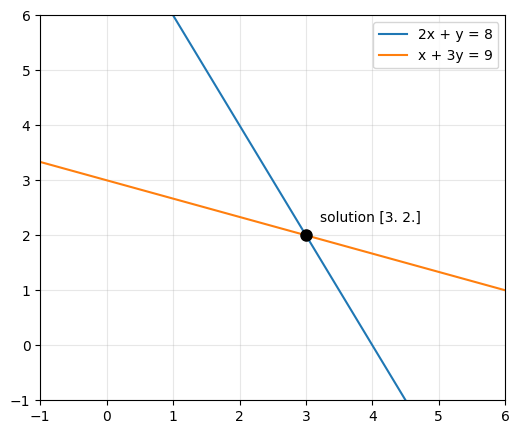

In [2]:
# Row picture: each equation is a line; the solution is the intersection.
x = np.linspace(-1, 6, 100)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(x, 8 - 2 * x, label="2x + y = 8")
ax.plot(x, (9 - x) / 3, label="x + 3y = 9")
sol = np.linalg.solve(np.array([[2.0, 1.0], [1.0, 3.0]]), np.array([8.0, 9.0]))
ax.plot(*sol, "ko", ms=8)
ax.annotate(f"solution {sol}", sol, textcoords="offset points", xytext=(10, 10))
ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)
ax.grid(alpha=0.3); ax.legend()
plt.show()

## 4. Visualization — 解の3パターン

直線 2 本の位置関係は 3 つしかありません。これが解の 3 パターンに対応します。

| 直線の関係 | 解 |
|---|---|
| 交わる | ちょうど 1 つ |
| 平行で重ならない | 存在しない(矛盾) |
| 完全に重なる | 無限にある(直線全体) |

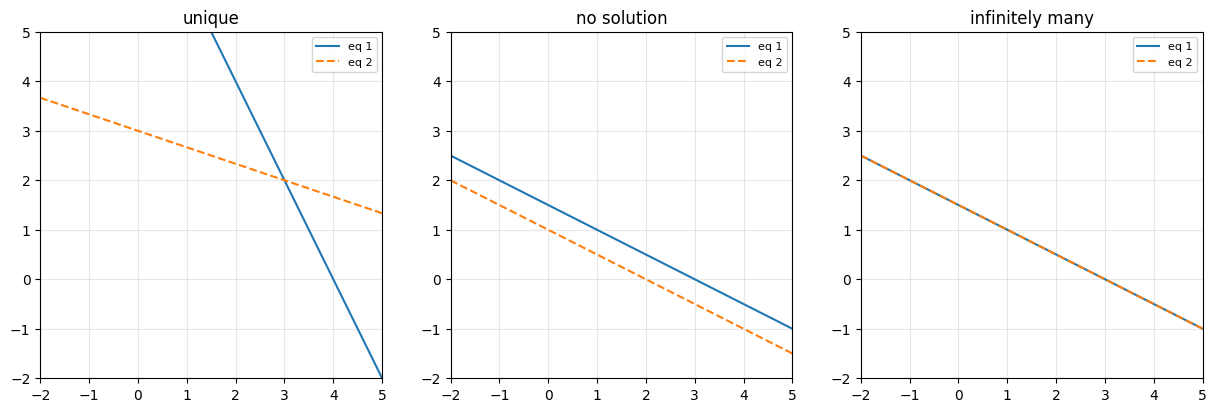

In [3]:
# The three possible pictures for a 2x2 system.
cases = [
    ("unique",      [[2, 1], [1, 3]],  [8, 9]),
    ("no solution", [[1, 2], [2, 4]],  [3, 4]),   # parallel lines
    ("infinitely many", [[1, 2], [2, 4]], [3, 6]),  # same line twice
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
xs = np.linspace(-2, 5, 100)
for ax, (name, M, b) in zip(axes, cases, strict=True):
    (a1, a2), (c1, c2) = M
    ax.plot(xs, (b[0] - a1 * xs) / a2, label="eq 1")
    ax.plot(xs, (b[1] - c1 * xs) / c2, "--", label="eq 2")
    ax.set_title(name)
    ax.set_xlim(-2, 5); ax.set_ylim(-2, 5)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()

## 5. Definition — 掃き出し法・ランク・基底

**掃き出し法(Gauss-Jordan 消去法)。** 次の 3 つの **行基本変形** だけを使って、
方程式を解ける形まで単純化する手続きです。

1. 2 つの行を入れ替える
2. ある行を 0 でない定数倍する
3. ある行に別の行の定数倍を加える

どの操作も「方程式の言い換え」なので、**解の集合は一切変わりません**。
行き着く先の標準形を **簡約行階段形(RREF)** と呼びます。
各行の先頭の 1(**ピボット**)が階段状に並んだ形です。

**ランク**: RREF に残ったピボットの個数。
列の絵で言えば「$A$ の列が実質的に張れる空間の次元」=「出力に残る情報の次元」。

**基底**: 空間を「過不足なく」張るベクトルの組。
(1) 線形結合でその空間のすべてを作れて(張る)、(2) どの 1 本も他から作れない(線形独立)。
基底の本数はどう選んでも同じで、それを **次元** と呼びます。

**核と像**:

- **像(列空間)** $\,\mathrm{Im}\,A = \{Ax \mid x \in \mathbb{R}^n\}$ — 出力としてあり得るベクトル全体。次元 = ランク。
- **核(零空間)** $\,\mathrm{Ker}\,A = \{x \mid Ax = 0\}$ — 0 につぶされてしまう入力全体。

そして次の **次元定理(ランク・退化次数の定理)** が成り立ちます。

$$
\dim(\mathrm{Ker}\,A) + \mathrm{rank}\,A = n
$$

「つぶれた次元 + 生き残った次元 = 入力の次元」。情報の収支決算です。

## 6. Computation — 掃き出し法を動かす

まず `la_book.algebra.rref`(浮動小数点 + 部分ピボット選択)で RREF を計算し、
SymPy の厳密計算と一致することも確かめます。

In [4]:
# Solve the diet problem by row reduction on the augmented matrix [A | b].
Ab = np.array([[2.0, 1.0, 8.0],
               [1.0, 3.0, 9.0]])
R, pivots = algebra.rref(Ab)
print("RREF of [A|b]:\n", R)
print("pivot columns:", pivots)
print("-> x =", R[0, 2], ", y =", R[1, 2])

RREF of [A|b]:
 [[1. 0. 3.]
 [0. 1. 2.]]
pivot columns: [0, 1]
-> x = 3.0 , y = 2.0


In [5]:
# Exact arithmetic with SymPy agrees.
R_exact, piv = sp.Matrix([[2, 1, 8], [1, 3, 9]]).rref()
R_exact

Matrix([
[1, 0, 3],
[0, 1, 2]])

In [6]:
# numpy's solver gives the same answer (it uses LU internally, see ch. 05/06).
A = np.array([[2.0, 1.0], [1.0, 3.0]])
b = np.array([8.0, 9.0])
print("solve:", np.linalg.solve(A, b))

solve: [3. 2.]


### ランクと核・像を計算する

3 本の列を持つのに「実質 2 次元分」しか張れない行列で確かめます。
第 3 列 = 第 1 列 + 第 2 列、という冗長な行列です。

In [7]:
# A redundant matrix: col3 = col1 + col2, so the rank is 2, not 3.
B = np.array([[1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0],
              [1.0, 1.0, 2.0]])
R, pivots = algebra.rref(B)
print("RREF:\n", R)
print("rank =", algebra.rank(B), " (numpy agrees:", np.linalg.matrix_rank(B), ")")

RREF:
 [[1. 0. 1.]
 [0. 1. 1.]
 [0. 0. 0.]]
rank = 2  (numpy agrees: 2 )


In [8]:
# Kernel (null space): inputs that the matrix crushes to zero.
ns = sp.Matrix(B).nullspace()
print("null space basis (sympy):", [list(v) for v in ns])

# Check: B @ (1, 1, -1) = 0, so dim Ker = 1 and rank-nullity holds: 1 + 2 = 3.
k = np.array([1.0, 1.0, -1.0])
print("B @ k =", B @ k)

null space basis (sympy): [[-1.00000000000000, -1.00000000000000, 1]]
B @ k = [0. 0. 0.]


### ピボット列が像(列空間)の基底になる

RREF のピボットが第 1, 2 列に立ったので、
**元の行列の** 第 1, 2 列が列空間の基底です(RREF の列ではない点に注意)。
第 3 列はその線形結合で書けるので、基底には入れません。

In [9]:
# col3 is exactly col1 + col2: the pivot columns {col1, col2} form a basis of Im(B).
print("col1 + col2 =", B[:, 0] + B[:, 1])
print("col3        =", B[:, 2])

col1 + col2 = [1. 1. 2.]
col3        = [1. 1. 2.]


## 7. Invariant — 行基本変形で保存されるもの

- **解の集合**: 3 つの行基本変形はすべて可逆な言い換えなので、解は増えも減りもしない。
- **行空間とランク**: 行の張る空間は変形の前後で同一。だから「RREF で数えたピボット数」を
  元の行列のランクと呼んでよい。
- **核**: $Ax=0$ の解集合も不変。

一方で **列空間は行基本変形で変わる** ことに注意(基底の「番地」=ピボット列の位置だけが保存されます)。

## 8. Failure Mode — ランク落ちで情報が失われる

ランクが落ちた行列を通すと、何が起きるか。
3 次元の点群を、ランク 3(正則)・ランク 2・ランク 1 の行列で変換してみます。

- ランク 3: 雲は形を変えるが、3 次元のまま → 復元可能
- ランク 2: 雲が **平面にぺたんこ** になる → 奥行き情報は永久に失われる
- ランク 1: 雲が **1 本の直線** に → 残る情報は 1 次元分だけ

「逆行列が無い」とは、この **不可逆な圧縮** が起きたということです。

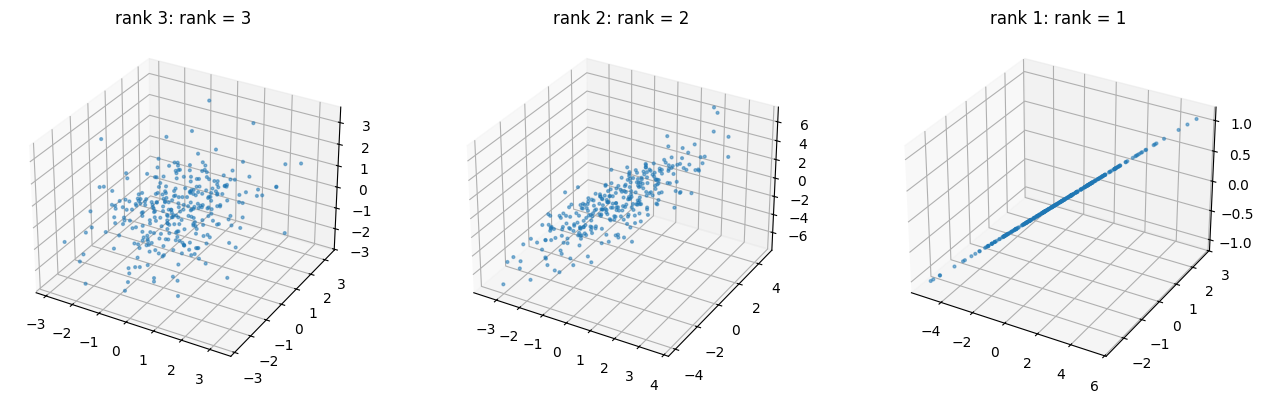

In [10]:
# Project a 3-D cloud through matrices of rank 3, 2, 1 and watch dimensions die.
rng = np.random.default_rng(42)
cloud = rng.standard_normal((300, 3))

M3 = np.array([[1.0, 0.2, 0.1], [0.1, 1.0, 0.3], [0.0, 0.2, 1.0]])  # rank 3
M2 = np.array([[1.0, 0.0, 1.0], [0.0, 1.0, 1.0], [1.0, 1.0, 2.0]])  # rank 2
M1 = np.outer([1.0, 0.5, 0.2], [1.0, 1.0, 1.0])                     # rank 1

fig = plt.figure(figsize=(16, 4.5))
for i, (M, name) in enumerate([(M3, "rank 3"), (M2, "rank 2"), (M1, "rank 1")]):
    out = cloud @ M.T
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.scatter(*out.T, s=4, alpha=0.5)
    ax.set_title(f"{name}: rank = {np.linalg.matrix_rank(M)}")
plt.show()

数値計算では「厳密にはランク落ちしていないが、ほぼ落ちている」行列がさらに厄介です
(ほぼ平行な直線の交点は、わずかな誤差で大きく動く)。これは 06 章の **条件数** で扱います。

## 9. Application — 補間も CT スキャンも連立方程式

3 点 $(0, 1), (1, 3), (2, 9)$ を通る放物線 $y = c_0 + c_1 x + c_2 x^2$ を求める問題は、
係数 $(c_0, c_1, c_2)$ についての連立一次方程式です(未知数が「係数」である点がミソ)。

CT スキャンも本質は同じで、「各方向からの X 線の吸収量(=画素値の和)」という
何万本もの一次方程式から、体内の画素値を復元しています。

Vandermonde matrix:
 [[1. 0. 0.]
 [1. 1. 1.]
 [1. 2. 4.]]
coefficients c0, c1, c2 = [1. 0. 2.]


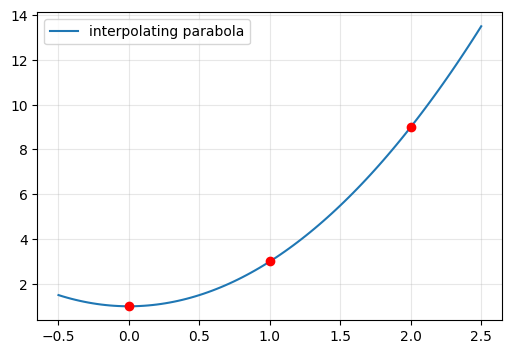

In [11]:
# Fit an exact parabola through 3 points: a linear system in the coefficients.
pts_x = np.array([0.0, 1.0, 2.0])
pts_y = np.array([1.0, 3.0, 9.0])
V = np.vander(pts_x, 3, increasing=True)  # rows: [1, x, x^2]
coef = np.linalg.solve(V, pts_y)
print("Vandermonde matrix:\n", V)
print("coefficients c0, c1, c2 =", coef)

xs = np.linspace(-0.5, 2.5, 100)
plt.figure(figsize=(6, 4))
plt.plot(xs, coef[0] + coef[1] * xs + coef[2] * xs**2, label="interpolating parabola")
plt.scatter(pts_x, pts_y, color="red", zorder=3)
plt.grid(alpha=0.3); plt.legend()
plt.show()

## 10. Exercises

1. 連立方程式 $x + 2y = 5,\ 3x - y = 1$ を、拡大係数行列の掃き出しで手で解け。
   `algebra.rref` で検算せよ。
2. 上の「解なし」「解が無限」の 2 ケースについて、拡大係数行列の RREF を計算し、
   どの行が矛盾(または自由変数)を示しているか確認せよ。
3. 行列 $\begin{pmatrix} 1 & 2 & 3 \\ 2 & 4 & 6 \\ 1 & 1 & 1 \end{pmatrix}$ のランク、核の基底、像の基底を求めよ。
4. ランク 1 の $3 \times 3$ 行列を 1 つ作り、3 次元点群がどんな図形につぶれるか描画せよ。
5. 4 点 $(0,1), (1,2), (2,5), (3,10)$ を通る 3 次多項式を、Vandermonde 行列を作って求めよ。
6. (発展)$m < n$(方程式より未知数が多い)のとき、$Ax = b$ に一意解があり得ないことを
   次元定理から説明せよ。

## 11. Advanced Notes

**次元定理の証明スケッチ。** $\mathrm{Ker}\,A$ の基底 $u_1, \dots, u_k$ を取り、
それを $\mathbb{R}^n$ の基底 $u_1, \dots, u_k, w_1, \dots, w_{n-k}$ に延長する。
このとき $Aw_1, \dots, Aw_{n-k}$ が $\mathrm{Im}\,A$ の基底になることを示せばよい。
張ることは任意の $x$ を基底で展開すれば出る。独立性は、
$\sum c_i A w_i = 0 \Rightarrow \sum c_i w_i \in \mathrm{Ker}\,A \Rightarrow$
核の基底で書けるが $w_i$ の独立性から $c_i = 0$、と進む。

**行ランク = 列ランク。** 「行の張る空間の次元」と「列の張る空間の次元」が常に一致するのは
自明ではない定理です。RREF を経由する証明(ピボット数が両方を支配する)が最短ですが、
05 章の SVD を使うと「ランク = 0 でない特異値の個数」として対称性が一目で分かります。

**解の存在と一意性の整理。**

$$
Ax = b \ \text{is solvable} \iff \mathrm{rank}\,A = \mathrm{rank}\,[A \mid b]
$$

解があるとき、解集合は「特殊解 + 核」という平行移動されたアフィン部分空間:

$$
x = x_p + z, \qquad z \in \mathrm{Ker}\,A
$$

一意 $\iff \mathrm{Ker}\,A = \{0\} \iff \mathrm{rank}\,A = n$(列フルランク)。

**数値計算上の注意。** 浮動小数点でランクを「ピボットが 0 かどうか」で判定するのは危険です
(`1e-15` は 0 か?)。実務では SVD の特異値に閾値を設けて数えます
(`np.linalg.matrix_rank` の実装もそうなっています)。